# Topic Modeling: Latent Dirichlet Allocation vs. BERTopic

In [1]:
import json
import pandas as pd
import numpy as np
import random
import re

import matplotlib.pyplot as plt
import plotly.express as px
import seaborn as sns
%matplotlib inline

## Exploratory Data Analysis

We are using the [Starbucks Reviews Dataset](https://www.kaggle.com/datasets/harshalhonde/starbucks-reviews-dataset/data), curated by Harshal H.

In [2]:
# Import data and display first few rows
data = pd.read_csv('starbucks_reviews.csv')
print('Starbucks Reviews Dataset Size:', data.shape)
data.head()

Starbucks Reviews Dataset Size: (850, 6)


,name,location,Date,Rating,Review,Image_Links
0,Helen,"Wichita Falls, TX","Reviewed Sept. 13, 2023",5.0,Amber and LaDonna at the Starbucks on Southwes...,['No Images']
1,Courtney,"Apopka, FL","Reviewed July 16, 2023",5.0,** at the Starbucks by the fire station on 436...,['No Images']
2,Daynelle,"Cranberry Twp, PA","Reviewed July 5, 2023",5.0,I just wanted to go out of my way to recognize...,['https://media.consumeraffairs.com/files/cach...
3,Taylor,"Seattle, WA","Reviewed May 26, 2023",5.0,Me and my friend were at Starbucks and my card...,['No Images']
4,Tenessa,"Gresham, OR","Reviewed Jan. 22, 2023",5.0,I’m on this kick of drinking 5 cups of warm wa...,['https://media.consumeraffairs.com/files/cach...


In [3]:
# Notice that the above review text is truncated. 
# If you want to see full reviews, you can use the `display.max_colwidth` option.
pd.set_option('display.max_colwidth', None)
data['Review'].sample(10)

544    My husband disabled has brain damage as well as some physical disabilities from a car crash. He also happens to be Mexican American. Neither are acceptable it seems to the fine people of Starbucks on Feland and Shaw in Fresno Ca. One day my husband and I sit outside of Starbucks and I go in to make our order and I am standing in line when I hear an Anglo woman complaining about immigrants to one of the Starbucks baristas who to my dismay is totally agreeing with this racist old lady. I felt embarrassed as I am Spanish and felt it was inappropriate. Well I'm waiting for a while in line when my husband knocks on the window to change his drink request with me. Its a hundred and ten degrees outside so he is sweating like mad, also a result of his disability. Well the female blonde haired barista looks at him in horror and says to the racist Anglo lady, "There's one of them now." She meant immigrants these two Anglo females were complaining about. She turns to me with this look of ha

In [4]:
# Inspect all the columns, their types, and how many rows are nulls. 
# No reviews are nulls, which is a little suspicious.
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 850 entries, 0 to 849
Data columns (total 6 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   name         850 non-null    object 
 1   location     850 non-null    object 
 2   Date         850 non-null    object 
 3   Rating       705 non-null    float64
 4   Review       850 non-null    object 
 5   Image_Links  850 non-null    object 
dtypes: float64(1), object(5)
memory usage: 40.0+ KB


In [5]:
# Let's see if any of the reviews are redundant (or if there is a default "null" review).
data.groupby(['Review'])['Review'].agg(['count']).sort_values(by='count', ascending=False)

,count
Review,
No Review Text,37
I then decided to call and ask her for her manager's #. She hung up on me 6 times after that and would not give me any #'s or names of her superior. The last time she answered and stated that I was getting the employee I asked to speak with in trouble. I am a regular at starbucks but after this crap I will go It's A Grind. I purchase coffe drinks 5-7 times a week too!,1
"ONLINE STORE IS USELESS. You can only call Mon.-Fri. 8 a.m.-5 p.m -- terrible customer service. Takes 10 days before they ship the order. Now they are using lowest level of delivery, takes 7-10 days to arrive. They are continually out of stock on items. Emails are not answered promptly. When they do answer they tell you it will ship and then it doesn't.",1
"My sweetheart and I went into our neighborhood Starbucks to get a coffee. We were standing waiting to be served looked at the food on display and noticed there was flies landing on the food and flying around. We pulled an employee aside and gestured towards the food and he said, ""Yes we are aware and it’s just a display we are not serving any of that to the public."" We were satisfied with that response and not more than 30 seconds go by and we witness a barista taking food out of the fly infested case put in oven to warm up for the public.",1
"My wife and I were at the Starbucks location at Bay St. and Cumberland here in Toronto. We are loyal customers, but this particular day, Saturday, April 14, 20012, was not very pleasant. I was pick-pocketed. My wallet was gone. I know it’s not your fault, but it’s easy target where your seats are at one point being very narrow. Hoards of people collect at one time and that’s where it happened. We truly enjoy your espressos and cappuccinos. Unfortunately, because of this incident, we will not be returning to this location and we will be informing our friends to be vigilant when going there. This was very unfortunate.",1
...,...
"I like the rewards program and the variety of drinks and specials. They have a good attitude, always ready to serve and make the drink the way you want it.",1
I like the way the set up is in the store and also the ambiance. The staff are nice and courteous. I like the different drinks and food items that are healthy choices.,1
"I like your product, particularly your coffee but notice that your cups, more often than not, tend to leak at the seam when the lid is in place. I have plenty of ruined shirts and a big dry cleaning bill to prove it.",1


In [6]:
# Remove rows that have a review of "No Review Text".
data = data[ data.Review != 'No Review Text' ].copy()
print('Starbucks Reviews w/Text Dataset Size:', data.shape)

Starbucks Reviews w/Text Dataset Size: (813, 6)


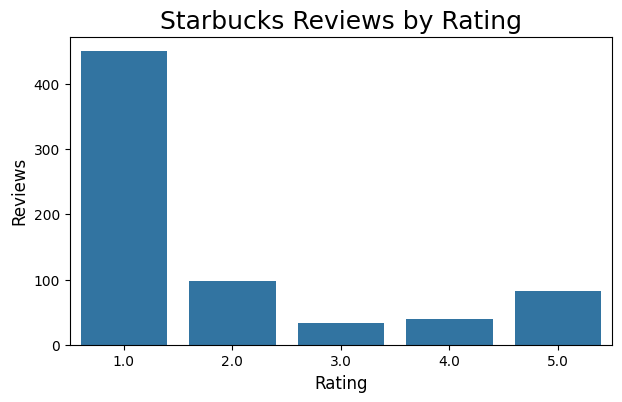

In [7]:
# Simple barchart to see count of reviews by rating.
plt.figure(figsize=(7,4))
sns.countplot(data=data, x='Rating')
plt.title('Starbucks Reviews by Rating', fontsize=18)
plt.xlabel('Rating', fontsize=12)
plt.ylabel('Reviews', fontsize=12)
plt.show()

In [8]:
# Because reviews are so heavily negative, let's model 1-2 star reviews and see what's up.
df = data[ data.Rating <= 2 ].copy()
print('Starbucks Negative Reviews Dataset Size:', df.shape)

Starbucks Negative Reviews Dataset Size: (548, 6)


## Data Preparation

In [9]:
import nltk
from nltk.corpus import stopwords
from gensim.parsing.preprocessing import STOPWORDS as gensimSTOPWORDS
import spacy

In [10]:
# Stop word list
stop_words = set(stopwords.words('english'))
stop_words.update(gensimSTOPWORDS)
stop_words.update(['starbuck','starbucks','coffee','drink'])
stop_words = list(stop_words)

print(stop_words[:10])

['km', 'whereupon', 'she', 'latterly', 'i', 'mill', 'either', 'he', 'out', 'throughout']


In [11]:
# Lemmatizer
nlp = spacy.load('en_core_web_md', disable=['parser', 'ner'])

In [12]:
# Tokens: There are a lot of great tokenizers out there, but here we make a simple one
docs = df.Review.to_list()
tokens = []

for doc in docs:
    doc = str(doc).lower()
    chars = "`*{}[]()<>#+=;,.:!$?"  # remove punctuation
    for c in chars:
        if c in doc:
            doc = doc.replace(c, ' ')
    doc = re.sub('\"','',doc)  # remove double quotes
    doc = re.sub('-','_',doc)  # remove hypens
    doc = doc.replace('/n',' ')  # remove carriage returns
    doc = re.sub('\s+',' ',doc)  # remove extra spaces
    
    # LDA performs much better with lemmitization than stemming
    doc = [ word for word in nlp(doc) if len(word) > 1 ]
    doc = [ token.lemma_ for token in doc ]
    doc = [ word.lower() for word in doc if word.lower() not in stop_words and word.isalpha() ]
    tokens.append(doc)

df['doc'] = docs          ## For BERTopic
df['tokens'] = tokens     ## For LDA
df['token_count'] = [ len(doc) for doc in tokens ]

In [13]:
# Check out our new lemmatized reviews.
df.head(5)

,name,location,Date,Rating,Review,Image_Links,doc,tokens,token_count
5,Alyssa,"Sunnyvale, TX","Reviewed Sept. 14, 2023",1.0,We had to correct them on our order 3 times. They never got it right then the manager came over to us and said we made her employee uncomfortable because we were trying to correct our order. The manager tried was racist against my stepmom (Chinese) taking over her but when I (**) would talk she would stop talking and listen to me.,['No Images'],We had to correct them on our order 3 times. They never got it right then the manager came over to us and said we made her employee uncomfortable because we were trying to correct our order. The manager tried was racist against my stepmom (Chinese) taking over her but when I (**) would talk she would stop talking and listen to me.,"[correct, order, time, right, manager, come, employee, uncomfortable, try, correct, order, manager, try, racist, stepmom, chinese, talk, stop, talk, listen]",20
6,ken,"Spring Hill, FL","Reviewed Sept. 8, 2023",1.0,"I have tried Starbucks several different times in different locations just in case it was just the one store. But it's not. If you like coffee that taste like dirt scooped off the ground at a garbage dump, then this is the place for you.",['No Images'],"I have tried Starbucks several different times in different locations just in case it was just the one store. But it's not. If you like coffee that taste like dirt scooped off the ground at a garbage dump, then this is the place for you.","[try, different, time, different, location, case, store, like, taste, like, dirt, scoop, ground, garbage, dump, place]",16
7,Nikki,"Asheville, NC","Reviewed Aug. 25, 2023",1.0,"Starbucks near me just launched new fall foods and beverages yesterday. By noon yesterday they were out of all new items. The fall launch is huge and many people look forward to it all year. Maybe if you don’t have enough product to last even a couple of days, push back the launch until you do? I was so happy to get the email that it had come out that I left work on my break to brighten my day and so very disappointed to get there at 12:30pm and find out that it was all gone. Please Starbucks, do better.",['No Images'],"Starbucks near me just launched new fall foods and beverages yesterday. By noon yesterday they were out of all new items. The fall launch is huge and many people look forward to it all year. Maybe if you don’t have enough product to last even a couple of days, push back the launch until you do? I was so happy to get the email that it had come out that I left work on my break to brighten my day and so very disappointed to get there at 12:30pm and find out that it was all gone. Please Starbucks, do better.","[near, launch, new, fall, food, beverage, yesterday, noon, yesterday, new, item, fall, launch, huge, people, look, forward, year, maybe, product, couple, day, push, launch, happy, email, come, leave, work, break, brighten, day, disappointed]",33
8,Alex,"Reisterstown, MD","Reviewed Aug. 5, 2023",1.0,"I ordered online for the Reisterstown Rd, St Thomas SC 99000 and they gave me the wrong drink size so ordered a venti they gave me a grande. Just a bit upset that I paid over 5 bucks for a drink and got the wrong thing.",['No Images'],"I ordered online for the Reisterstown Rd, St Thomas SC 99000 and they gave me the wrong drink size so ordered a venti they gave me a grande. Just a bit upset that I paid over 5 bucks for a drink and got the wrong thing.","[order, online, reisterstown, rd, st, thomas, sc, wrong, size, order, venti, grande, bit, upset, pay, buck, wrong, thing]",18
9,Sunny,"Zionville, Other","Reviewed Aug. 4, 2023",1.0,"Staff at the Smythe St. Superstore location in Fredericton, NB often seen tired but today, a woman named Senoa (Senora?) was morose, glum, uncommunicative (even after I tried to engage her to sympathize, as there was obviously a bad mood happening), scruffy looking, almost rude. And, the Americano I ordered tastes watery. I go t

In [14]:
# It is always good to do a detailed review to see how our text was transformed.
i = random.randint(0,len(docs))
print(docs[i])
print(tokens[i])

My husband goes to the Virginia Hills Starbucks in Martinez, CA every morning for our coffee. I always have a Venti Cinnamon Latte. For the last two months the amount in the cup has been getting less and less. This morning my latte level was at the third square down that reads syrup. I'm sorry, but for the amount of money we pay for this I expect the cup to be pretty full. This may seem like a small thing to complain about but I can tell you this is the first time I have ever made a customer complaint so it isn't small to me. I won't be buying from this Starbucks again.
['husband', 'virginia', 'hills', 'martinez', 'morning', 'venti', 'cinnamon', 'latte', 'month', 'cup', 'morning', 'latte', 'level', 'square', 'read', 'syrup', 'sorry', 'money', 'pay', 'expect', 'cup', 'pretty', 'like', 'small', 'thing', 'complain', 'tell', 'time', 'customer', 'complaint', 'small', 'buy']


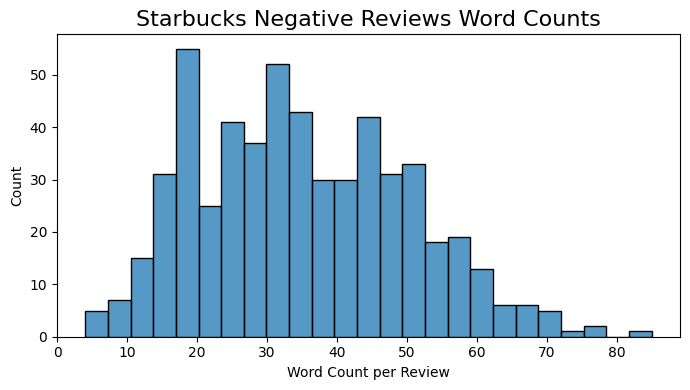

In [15]:
# Check review token count distribution
fig = plt.figure(figsize=(7,4))
sns.histplot(x='token_count', data=df, bins=25)
plt.title('Starbucks Negative Reviews Word Counts', fontsize=16)
plt.xlabel('Word Count per Review')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

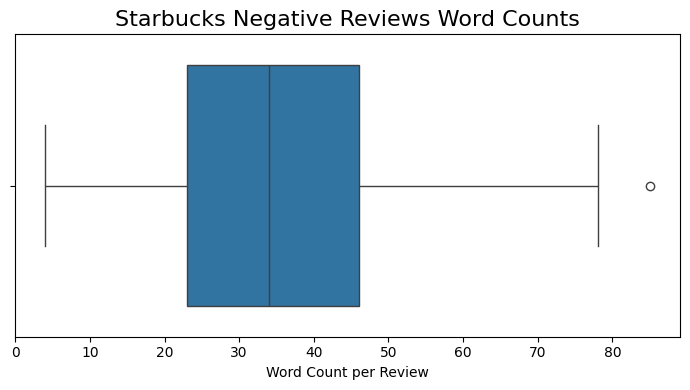

In [16]:
fig = plt.figure(figsize=(7,4))
sns.boxplot(x='token_count', data=df)
plt.title('Starbucks Negative Reviews Word Counts', fontsize=16)
plt.xlabel('Word Count per Review')
plt.tight_layout()
plt.show()

In [17]:
# Remove reviews that have fewer than 10 and more than 70 tokens.
df.drop(df[(df.token_count < 10) | (df.token_count > 70)].index, inplace=True)

## Latent Dirichlet Allocation (LDA)

In [18]:
from gensim import corpora, models
import pyLDAvis
import pyLDAvis.gensim

import os
os.environ["TOKENIZERS_PARALLELISM"] = "false"

###  LDA Tuning

In [19]:
# Create dictionary and corpus.
texts = df.tokens.to_list()
id2word = corpora.Dictionary(texts)
corpus = [ id2word.doc2bow(doc) for doc in texts ]

In [21]:
# Feel free to play around with this tuning code. Generally, we look for higher coherence and lower perplexity.
# Interestingly, the best coherence and perplexity scores do not always lead to the best model.
# Some elements of topic models are still more art than science.

if 1 == 0:
    ks = [ 6, 7, 8, 9, 10, 11, 12 ]
    # alphas = ['symmetric','asymmetric',0.01,0.1,1,10,100]
    alphas = ['asymmetric']
    betas = ['symmetric',0.01,0.1,1,10,25]
    results = []

    for k in ks:
        for alpha in alphas:
            for beta in betas:
                lda_model = models.ldamodel.LdaModel(
                                                corpus=corpus,
                                                id2word=id2word,
                                                num_topics=k, 
                                                random_state=38,
                                                #chunksize=2000,
                                                passes=10,
                                                alpha=alpha,
                                                eta=beta,
                                                per_word_topics=True
                ) 
                lda_coherence = models.CoherenceModel(model=lda_model, corpus=corpus, dictionary=id2word, texts=texts, coherence='c_v').get_coherence()
                lda_perplexity = lda_model.log_perplexity(corpus)
                results.append([k, alpha, beta, lda_coherence, lda_perplexity])

lda_tuning = pd.DataFrame(results, columns=['k','alpha','beta','coherence','perplexity'])
lda_tuning.to_csv('lda/lda_tuning.csv', index=False)

### LDA Model

In [20]:
# Best parameters from tuning actually leads to a bad topic model.
# k: 8
# alpha: asymmetric
# beta: 10
# LDA Coherence: 0.4706690032932236
# LDA Perplexity: -7.674040753577471

if 1 == 0:
    lda_model = models.ldamodel.LdaModel(
                    corpus=corpus,
                    id2word=id2word,
                    num_topics=15,
                    random_state=38,
                    #chunksize=2000,
                    passes=10,
                    alpha='auto',
                    per_word_topics=True
    ) 
    lda_model.save('lda/lda.model')

In [23]:
# Load previously saved model.
lda_model = models.ldamodel.LdaModel.load('lda/lda.model')

In [24]:
# Coherence and perplexity scores.
lda_coherence = models.CoherenceModel(model=lda_model, corpus=corpus, dictionary=id2word, texts=texts, coherence='c_v').get_coherence()
lda_perplexity = lda_model.log_perplexity(corpus)

print('LDA Coherence:', lda_coherence)
print('LDA Perplexity:', lda_perplexity)

LDA Coherence: 0.3221518979172175
LDA Perplexity: -7.614709822961153


In [25]:
# pyLDAvis is probably the best way to evaluate the model.
LDAvis_prepared = pyLDAvis.gensim.prepare(lda_model, corpus, id2word, sort_topics=False)
pyLDAvis.save_html(LDAvis_prepared, f'lda/lda_pyLDAvis.html')

In [26]:
# print_topics allows you sto see which words are making up each topic.
lda_model.print_topics(num_topics=-1)

[(0,
  '0.027*"order" + 0.013*"wait" + 0.013*"leave" + 0.011*"customer" + 0.011*"use" + 0.011*"tea" + 0.010*"tell" + 0.009*"employee" + 0.008*"tip" + 0.008*"time"'),
 (1,
  '0.015*"time" + 0.012*"pay" + 0.012*"location" + 0.012*"ask" + 0.011*"customer" + 0.008*"sit" + 0.008*"home" + 0.007*"service" + 0.007*"come" + 0.007*"card"'),
 (2,
  '0.033*"order" + 0.018*"ask" + 0.014*"wait" + 0.013*"customer" + 0.011*"tell" + 0.009*"store" + 0.009*"bad" + 0.009*"want" + 0.009*"think" + 0.008*"service"'),
 (3,
  '0.013*"customer" + 0.012*"cup" + 0.012*"like" + 0.010*"ask" + 0.009*"order" + 0.008*"place" + 0.008*"want" + 0.008*"time" + 0.007*"service" + 0.007*"wait"'),
 (4,
  '0.023*"day" + 0.018*"customer" + 0.018*"service" + 0.015*"card" + 0.011*"store" + 0.011*"time" + 0.010*"bad" + 0.010*"receive" + 0.009*"tell" + 0.009*"purchase"'),
 (5,
  '0.016*"card" + 0.013*"customer" + 0.011*"location" + 0.011*"year" + 0.010*"ask" + 0.009*"buy" + 0.008*"come" + 0.008*"day" + 0.008*"store" + 0.007*"tell"'

In [27]:
# Add highest probability LDA topic for each review to the dataframe.
def get_lda_topics(tokens):
       corpus = id2word.doc2bow(tokens)
       topics = lda_model.get_document_topics(corpus, minimum_probability=0.1)
       topics_sorted = list(sorted(topics, key=lambda tup: tup[1], reverse=True))
       return topics_sorted

df['lda_topics'] = df.tokens.apply(lambda x: get_lda_topics(x))

In [28]:
df[['Review','lda_topics']].head(15)

,Review,lda_topics
5,We had to correct them on our order 3 times. They never got it right then the manager came over to us and said we made her employee uncomfortable because we were trying to correct our order. The manager tried was racist against my stepmom (Chinese) taking over her but when I (**) would talk she would stop talking and listen to me.,"[(7, 0.9760578)]"
6,"I have tried Starbucks several different times in different locations just in case it was just the one store. But it's not. If you like coffee that taste like dirt scooped off the ground at a garbage dump, then this is the place for you.","[(14, 0.9704625)]"
7,"Starbucks near me just launched new fall foods and beverages yesterday. By noon yesterday they were out of all new items. The fall launch is huge and many people look forward to it all year. Maybe if you don’t have enough product to last even a couple of days, push back the launch until you do? I was so happy to get the email that it had come out that I left work on my break to brighten my day and so very disappointed to get there at 12:30pm and find out that it was all gone. Please Starbucks, do better.","[(5, 0.98539597)]"
8,"I ordered online for the Reisterstown Rd, St Thomas SC 99000 and they gave me the wrong drink size so ordered a venti they gave me a grande. Just a bit upset that I paid over 5 bucks for a drink and got the wrong thing.","[(0, 0.9733096)]"
9,"Staff at the Smythe St. Superstore location in Fredericton, NB often seen tired but today, a woman named Senoa (Senora?) was morose, glum, uncommunicative (even after I tried to engage her to sympathize, as there was obviously a bad mood happening), scruffy looking, almost rude. And, the Americano I ordered tastes watery. I go to Starbucks for a treat after a long day. It a difficult experience, to ease stress and have a pleasant experience. I’m going to sell a different location after today’s grumpy girl.","[(5, 0.9890029)]"
10,"I filed a BBB complaint last month because Starbucks canceled my Starbucks Reward cards. I couldn't remember the balances, so I guessed about $9. Starbucks played nothing but games and tried everything they could to avoid responding to the complaint. I received a couple of phone call messages asking me to contact them directly and discuss the matter. The number provided was the customer service number and when I spoke with one representative, Linda hung up the phone on me. I did not use my card since 2012 which is my prerogative. Because of this and other reasons, Starbucks decided to close my Starbucks account. I reopened one about a few weeks ago and added a new card that I have not used yet.","[(11, 0.9899825)]"
11,"Every time I try to buy a Strawberry Refresher Starbucks never has strawberries to put into the drink. How is the drink called Strawberry Refresher and you guys never have any damn strawberries. It seems every time we go on the Starbucks to order a specialty drink you guys are constantly out of it. It’s like calling a pizza place, and they’re telling us they’re out of cheese. I don’t give you a partial payment so I don’t expect a partial drink.","[(7, 0.9807474)]"
12,Insulted by customer service representative as I called to complain instead of acknowledge they have issues and they are providing low quality. She called me suspicious even though I spend at least average 15 dollars a day. Was so upset and I decided to close the account after being with them for more than 10 yrs. Company that doesn't appreciate feedback soon to fall especially that it lost its quality.,"[(4, 0.9835325)]"
13,"I would give Starbucks zero stars if I could. I received an email that I would be receiving a birthday reward on the day of my birthday and it would be good on the day of my birthday only. The email also stated that the reward would be for any drink or food item. I went to an Starbucks near my home. The cashier told me my coupon had expired. I told her I don't have a coupon. Its a birthday reward. I ordered a sandw

## BERTopic

### BERTopic Tuning

In [30]:
import umap
import hdbscan
from sentence_transformers import SentenceTransformer
from tqdm import tqdm

In [42]:
# Remove repeated warnings from default BERTopic component libraries.
import warnings
warnings.filterwarnings(
    action="always",
    message="n_jobs value -1 overridden to 1 by setting random_state. Use no seed for parallelism.",
    category=UserWarning,
)
warnings.filterwarnings(
    action="always",
    message="`alltrue` is deprecated as of NumPy 1.25.0, and will be removed in NumPy 2.0. Please use `all` instead.",
    category=DeprecationWarning,
)

In [31]:
model_name = 'bertopic'
docs = df.doc.to_list()
reviews = df.Review.apply(lambda x: str(x)[:min(len(x),150)])

In [32]:
# Create embeddings
n = len(docs)
batch_size = 10

embedding_model = SentenceTransformer('all-MiniLM-L6-v2')
embeddings = np.zeros((n, embedding_model.get_sentence_embedding_dimension()))

for i in tqdm(range(0, n, batch_size)):
    i_end = min(i+batch_size, n)
    batch = docs[i:i_end]
    batch_embed = embedding_model.encode(batch, normalize_embeddings=True)
    embeddings[i:i_end,:] = batch_embed

100%|██████████| 54/54 [00:11<00:00,  4.56it/s]


In [35]:
# 3D Scatterplot
if 1 == 1:
    n_components = 25
    nns = [  2, 5, 10 ]
    mds = [ 0.1, 0.5, 0.99 ]
    metrics = [ 'euclidean', 'cosine' ]

    for n_neighbors in nns:
        for min_dist in mds:
            for metric in metrics:
                umap_model = umap.UMAP(n_components=n_components, n_neighbors=n_neighbors, min_dist=min_dist, metric=metric)
                reduced_embeddings = umap_model.fit_transform(embeddings)

                fig = px.scatter_3d(
                    x=reduced_embeddings[:,0], y=reduced_embeddings[:,1], z=reduced_embeddings[:,2],
                    custom_data=[reviews],
                )
                fig.update_traces(
                    hovertemplate="<br>".join([
                        "Review: %{customdata[0]}",
                    ])
                )

                fig.write_html(f'{model_name}/tuning_graphs/umap-topics-3d-parameter-tuning-{metric}-{n_neighbors}-{min_dist}.html', include_plotlyjs="cdn", full_html=False)

In [43]:
n_components = 50
n_neighbors = 10
min_dist = 0.5
metric = 'cosine'

fit = umap.UMAP(n_components=n_components, n_neighbors=n_neighbors, min_dist=min_dist, metric=metric, random_state=38)
reduced_embeddings = fit.fit_transform(embeddings)

/Users/kaspii/data_science/topic_modeling/.venv/lib/python3.10/site-packages/umap/umap_.py:1943: UserWarning:

n_jobs value -1 overridden to 1 by setting random_state. Use no seed for parallelism.



In [38]:
clusterer = hdbscan.HDBSCAN()
clusterer.fit(reduced_embeddings)
clusterer.get_params()

/Users/kaspii/data_science/topic_modeling/.venv/lib/python3.10/site-packages/hdbscan/hdbscan_.py:1170: DeprecationWarning:

`alltrue` is deprecated as of NumPy 1.25.0, and will be removed in NumPy 2.0. Please use `all` instead.



{'algorithm': 'best',
 'allow_single_cluster': False,
 'alpha': 1.0,
 'approx_min_span_tree': True,
 'cluster_selection_epsilon': 0.0,
 'cluster_selection_method': 'eom',
 'core_dist_n_jobs': 4,
 'gen_min_span_tree': False,
 'leaf_size': 40,
 'match_reference_implementation': False,
 'max_cluster_size': 0,
 'memory': Memory(location=None),
 'metric': 'euclidean',
 'min_cluster_size': 5,
 'min_samples': None,
 'p': None,
 'prediction_data': False}

In [39]:
# check number of outliers
print(len(set(clusterer.labels_)))
print((clusterer.labels_ == -1).sum())

14
279


In [44]:
min_cls = [ 2, 3, 4, 5, 6, 7, 8, 9, 10]
min_smps = [None, 1, 2, 3, 4, 5]
outliers = []

for min_samples in tqdm(min_smps):
    for min_cluster_size in min_cls:
        clusterer = hdbscan.HDBSCAN(min_cluster_size=min_cluster_size, min_samples=min_samples)
        clusterer.fit(reduced_embeddings)

        outliers.append((f'min_cluster_size={min_cluster_size}, min_samples={min_samples}', len(set(clusterer.labels_)), 
            (clusterer.labels_ == -1).sum(), (.05 * df.shape[0]), (.1 * df.shape[0]), (.2 * df.shape[0]), (.3 * df.shape[0])))

  0%|          | 0/6 [00:00<?, ?it/s]/Users/kaspii/data_science/topic_modeling/.venv/lib/python3.10/site-packages/hdbscan/hdbscan_.py:1170: DeprecationWarning:

`alltrue` is deprecated as of NumPy 1.25.0, and will be removed in NumPy 2.0. Please use `all` instead.

/Users/kaspii/data_science/topic_modeling/.venv/lib/python3.10/site-packages/hdbscan/hdbscan_.py:1170: DeprecationWarning:

`alltrue` is deprecated as of NumPy 1.25.0, and will be removed in NumPy 2.0. Please use `all` instead.

/Users/kaspii/data_science/topic_modeling/.venv/lib/python3.10/site-packages/hdbscan/hdbscan_.py:1170: DeprecationWarning:

`alltrue` is deprecated as of NumPy 1.25.0, and will be removed in NumPy 2.0. Please use `all` instead.

/Users/kaspii/data_science/topic_modeling/.venv/lib/python3.10/site-packages/hdbscan/hdbscan_.py:1170: DeprecationWarning:

`alltrue` is deprecated as of NumPy 1.25.0, and will be removed in NumPy 2.0. Please use `all` instead.

/Users/kaspii/data_science/topic_modeling/.venv

In [45]:
outliers = sorted(outliers, key=lambda x: x[2])
hdbscan_df = pd.DataFrame(outliers, columns = ['params', 'clusters', 'outliers', 'sample_05_pct','sample_10_pct','sample_20_pct',
    'sample_30_pct'])
hdbscan_df.head(30)

,params,clusters,outliers,sample_05_pct,sample_10_pct,sample_20_pct,sample_30_pct
0,"min_cluster_size=8, min_samples=5",3,101,26.6,53.2,106.4,159.6
1,"min_cluster_size=9, min_samples=5",3,101,26.6,53.2,106.4,159.6
2,"min_cluster_size=10, min_samples=5",3,101,26.6,53.2,106.4,159.6
3,"min_cluster_size=4, min_samples=1",47,102,26.6,53.2,106.4,159.6
4,"min_cluster_size=3, min_samples=1",69,109,26.6,53.2,106.4,159.6
5,"min_cluster_size=2, min_samples=1",132,110,26.6,53.2,106.4,159.6
6,"min_cluster_size=5, min_samples=1",37,114,26.6,53.2,106.4,159.6
7,"min_cluster_size=9, min_samples=2",11,122,26.6,53.2,106.4,159.6
8,"min_cluster_size=10, min_samples=2",11,122,26.6,53.2,106.4,159.6
9,"min_cluster_size=6, min_samples=1",31,124,26.6,53.2,106.4,159.6


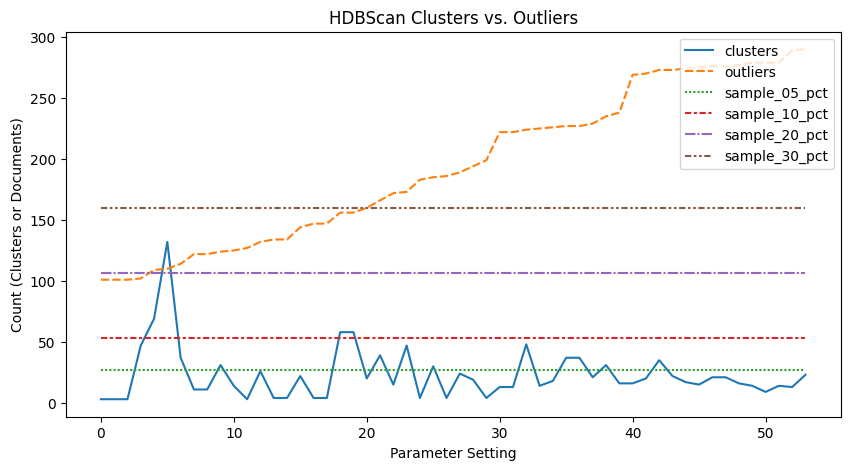

In [46]:
fig = plt.figure(figsize=(10,5))
sns.lineplot(data=hdbscan_df)
plt.legend(loc='upper right')
plt.title('HDBScan Clusters vs. Outliers')
plt.xlabel('Parameter Setting')
plt.ylabel('Count (Clusters or Documents)')
fig.savefig(f'{model_name}/tuning_graphs/hdbscan-cluster-outliers-{n_neighbors}-{min_dist}.png')
plt.show()

In [47]:
min_cluster_size = 10
min_samples = 1

clusterer = hdbscan.HDBSCAN(min_cluster_size=min_cluster_size, min_samples=min_samples)
clusterer.fit(reduced_embeddings)

/Users/kaspii/data_science/topic_modeling/.venv/lib/python3.10/site-packages/hdbscan/hdbscan_.py:1170: DeprecationWarning:

`alltrue` is deprecated as of NumPy 1.25.0, and will be removed in NumPy 2.0. Please use `all` instead.



HDBSCAN(min_cluster_size=10, min_samples=1)

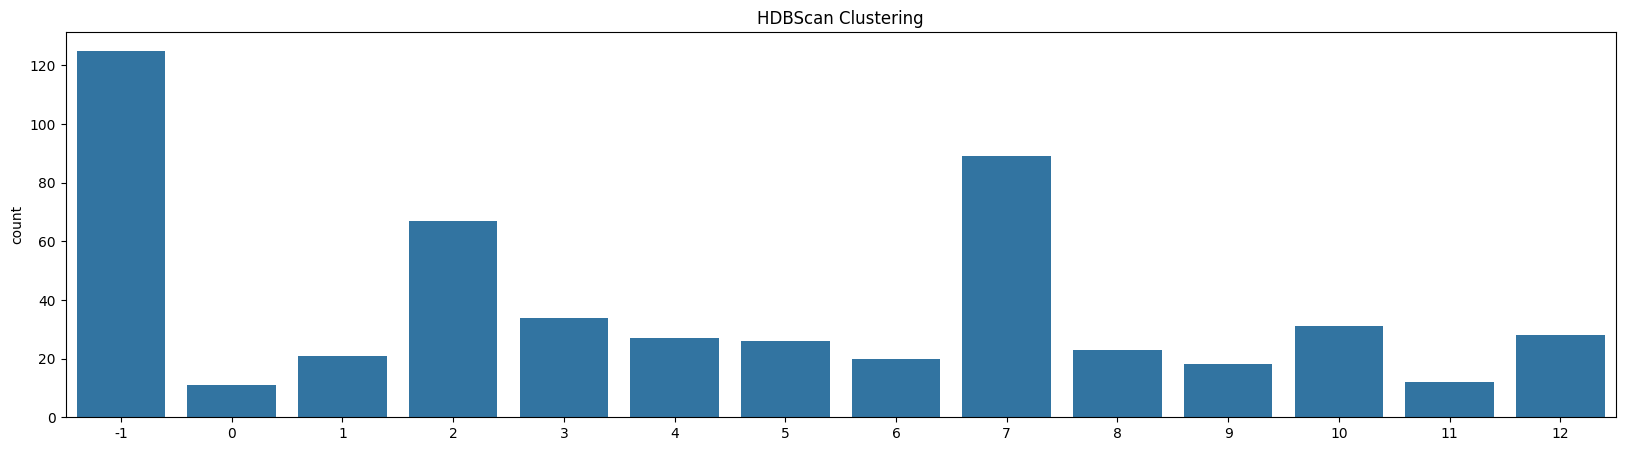

In [48]:
fig = plt.figure(figsize=(20,5))
sns.countplot(x=clusterer.labels_)
plt.title('HDBScan Clustering')
fig.savefig(f'{model_name}/tuning_graphs/hdbscan-cluster-counts-{n_neighbors}-{min_dist}-{min_cluster_size}-{min_samples}.png')
plt.show()

In [49]:
clusters = [str(x) for x in clusterer.labels_]
palette = sns.color_palette("hls",len(set(clusters))).as_hex()

fig = px.scatter_3d(
    x=reduced_embeddings[:,0], y=reduced_embeddings[:,1], z=reduced_embeddings[:,2],
    color=clusters,
    custom_data=[clusters,reviews],
    color_discrete_sequence=palette
)
fig.update_traces(
    hovertemplate="<br>".join([
        "cluster: %{customdata[0]}",
        "reivew: %{customdata[1]}"
    ])
)

fig.write_html(f'{model_name}/tuning_graphs/hdbscan-topics-3d-{n_neighbors}-{min_dist}-{min_cluster_size}-{min_samples}.html', include_plotlyjs="cdn", full_html=False)

### BERTopic Model

In [50]:
from bertopic import BERTopic
import umap
import hdbscan
from sklearn.feature_extraction.text import CountVectorizer

In [52]:
n_components = 50
n_neighbors = 10
min_dist = 0.5
metric = 'cosine'
min_cluster_size = 10
min_samples = 1

In [53]:
embedding_model = SentenceTransformer('all-MiniLM-L6-v2')
umap_model = umap.UMAP(n_neighbors=n_neighbors, n_components=n_components, min_dist=min_dist, metric=metric, random_state=38)
hdbscan_model = hdbscan.HDBSCAN(min_cluster_size=min_cluster_size, min_samples=min_samples, prediction_data=True, gen_min_span_tree=True)
vectorizer_model = CountVectorizer(ngram_range=(1, 2), stop_words=stop_words)

In [54]:
docs = df.doc.to_list()

topic_model = BERTopic(
    umap_model=umap_model,
    hdbscan_model=hdbscan_model,
    embedding_model=embedding_model,
    vectorizer_model=vectorizer_model,
    top_n_words=10,
    language='english',
    calculate_probabilities=True,
    verbose=True
)

topics, probs = topic_model.fit_transform(docs)
topic_model.get_params()

2024-02-22 07:31:34,111 - BERTopic - Embedding - Transforming documents to embeddings.
Batches: 100%|██████████| 17/17 [00:06<00:00,  2.82it/s]
2024-02-22 07:31:40,186 - BERTopic - Embedding - Completed ✓
2024-02-22 07:31:40,187 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm
2024-02-22 07:31:42,323 - BERTopic - Dimensionality - Completed ✓
2024-02-22 07:31:42,324 - BERTopic - Cluster - Start clustering the reduced embeddings
/Users/kaspii/data_science/topic_modeling/.venv/lib/python3.10/site-packages/hdbscan/hdbscan_.py:1170: DeprecationWarning:

`alltrue` is deprecated as of NumPy 1.25.0, and will be removed in NumPy 2.0. Please use `all` instead.

2024-02-22 07:31:42,411 - BERTopic - Cluster - Completed ✓
2024-02-22 07:31:42,414 - BERTopic - Representation - Extracting topics from clusters using representation models.
2024-02-22 07:31:42,590 - BERTopic - Representation - Completed ✓


{'calculate_probabilities': True,
 'ctfidf_model': ClassTfidfTransformer(),
 'embedding_model': <bertopic.backend._sentencetransformers.SentenceTransformerBackend at 0x190abbaf0>,
 'hdbscan_model': HDBSCAN(gen_min_span_tree=True, min_cluster_size=10, min_samples=1,
         prediction_data=True),
 'language': None,
 'low_memory': False,
 'min_topic_size': 10,
 'n_gram_range': (1, 1),
 'nr_topics': None,
 'representation_model': None,
 'seed_topic_list': None,
 'top_n_words': 10,
 'umap_model': UMAP(angular_rp_forest=True, metric='cosine', min_dist=0.5, n_components=50, n_neighbors=10, random_state=38, tqdm_kwds={'bar_format': '{desc}: {percentage:3.0f}%| {bar} {n_fmt}/{total_fmt} [{elapsed}]', 'desc': 'Epochs completed', 'disable': True}),
 'vectorizer_model': CountVectorizer(ngram_range=(1, 2),
                 stop_words=['km', 'whereupon', 'she', 'latterly', 'i', 'mill',
                             'either', 'he', 'out', 'throughout', 'which',
                             'without'

In [55]:
df['bertopic_topic'] = topic_model.topics_
df['bertopic_label'] = df['bertopic_topic'].apply(lambda x: topic_model.topic_labels_[x])
topic_model.save(f'{model_name}/model')

2024-02-22 07:31:42,702 - BERTopic - WARNING: When you use `pickle` to save/load a BERTopic model,please make sure that the environments in which you saveand load the model are **exactly** the same. The version of BERTopic,its dependencies, and python need to remain the same.


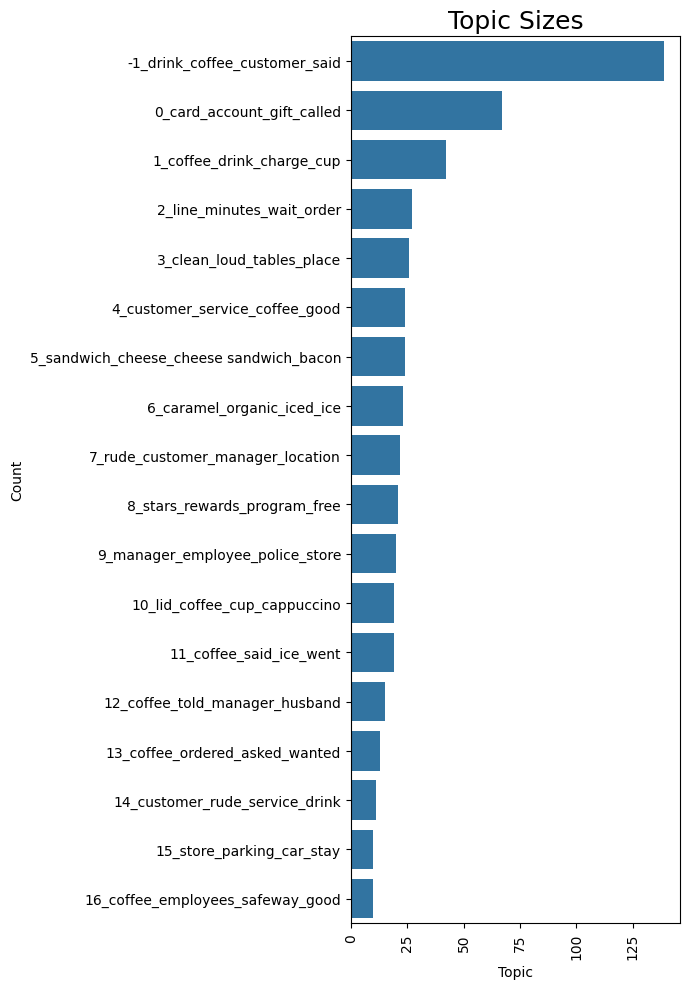

In [56]:
fig = plt.figure(figsize=(7,10))
sns.countplot(y='bertopic_label', data=df, order=df['bertopic_label'].value_counts().index)
plt.title('Topic Sizes', fontsize=18)
plt.xticks(rotation=90)
plt.xlabel('Topic')
plt.ylabel('Count')
plt.tight_layout()
fig.savefig(f'{model_name}/bertopic-topic-sizes.png')
plt.show()

In [57]:
rep_docs = { str(k) : v for k,v in topic_model.representative_docs_.items()}

with open(f'{model_name}/representative_documents.json', 'w') as f:
    f.write(json.dumps(rep_docs, indent=4))

In [58]:
fig = topic_model.visualize_barchart(top_n_topics=50, n_words=8, width=300)
fig.write_html(f'{model_name}/bertopic-topic-word-scores.html')
fig.show()

In [59]:
search_topics, search_similarity = topic_model.find_topics('manager was rude', top_n=3)
print(search_topics)
print(search_similarity)

[14, 7, 11]
[0.5660538, 0.45038065, 0.44563824]


In [60]:
reduced_embeddings = umap_model.fit_transform(embeddings)

In [61]:
clusters = df['bertopic_label']
palette = sns.color_palette("hls",len(set(clusters))).as_hex()
reviews = df.Review.apply(lambda x: str(x)[:min(len(x),250)])

fig = px.scatter_3d(
    x=reduced_embeddings[:,0], y=reduced_embeddings[:,1], z=reduced_embeddings[:,2],
    color=clusters,
    custom_data=[clusters,reviews],
    color_discrete_sequence=palette
)
fig.update_traces(
    hovertemplate="<br>".join([
        "cluster: %{customdata[0]}",
        "review: %{customdata[1]}"
    ])
)

fig.write_html(f'{model_name}/bertopic-3d.html', include_plotlyjs="cdn", full_html=False)
fig.show()

In [62]:
fig = topic_model.visualize_topics()
fig.write_html(f'{model_name}/bertopic-intertopic-distance.html')
fig.show()

In [63]:
fig = topic_model.visualize_hierarchy(custom_labels=True)
fig.write_html(f'{model_name}/bertopic-topic-hierarchy.html')
fig.show()

In [69]:
fig = topic_model.visualize_documents(docs, reduced_embeddings=reduced_embeddings)
fig.write_html(f'{model_name}/bertopic-topic-documents.html')
fig.show()

In [65]:
fig = topic_model.visualize_heatmap(custom_labels=True)
fig.write_html(f'{model_name}/bertopic-heatmap.html')
fig.show()